# Clasificación de Texto con BERT y Hugging Face

En este notebook implementaremos un clasificador de noticias en español utilizando transformers pero ya basandonos en un modelo pre-entrenado tipo Bidirectional Encoder Representation from Transformers o BERT por sus siglas y disponible en Hugging Face Hub. El propósito de esta tarea es aprender a utilizar modelos pre-entrenados que por si mismos, sería sumamente costoso entrenar desde cero, tanto por el poder de computo como la disponibilidad de datos de entrenamiento. Entonces gran parte de la labor ya ha sido realizada por nosotros. Nuestra tarea ahora es especializar el modelo en la tarea que tenemos a la mano.

En esta ocasión, vamos a apartarnos de Pytorch Lightning y harémos uso extensivo de la herramientas de Hugging Face, las cuales están especialmente desarrolladas para este tipo de tareas, incluyendo la interacción con modelos pre-entrenados.

#### Referencias
- Dataset: https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news
- [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/v4.41.3/en/index)
- [Hugging Face Accelerate](https://huggingface.co/docs/accelerate/index)
- [Hugging Face Evaluate](https://huggingface.co/docs/evaluate/v0.4.0/en/index)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/v2.19.0/en/index)

In [26]:
# Reproducibilidad y utilidades generales
import os, random, math, json, sys, platform, time
import numpy as np, torch
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Ajustes deterministas adicionales
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass
set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print('Torch version:', torch.__version__)
# Indicamos versiones clave para reproducibilidad posterior
import transformers, datasets, evaluate
print('transformers', transformers.__version__, 'datasets', datasets.__version__, 'evaluate', evaluate.__version__)

Using device: cuda
Torch version: 2.8.0+cu128
transformers 4.41.2 datasets 2.19.1 evaluate 0.4.2


In [27]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

In [ ]:
# Instalación condicional. En Colab instala todo; en local instala solo lo faltante.
import sys, subprocess, importlib
def pip_install(pkgs):
    cmd = [sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs
    try:
        subprocess.check_call(cmd)
        return True
    except Exception as e:
        print('[warn] pip install failed:', e)
        return False

required = ['datasets', 'transformers[torch]', 'sentence-transformers', 'torchinfo', 'evaluate', 'scikit-learn', 'seaborn', 'tensorboard']
if IN_COLAB:
    pip_install(required)
else:
    # Instala selectivamente lo faltante en local
    to_install = []
    name_map = {
        'datasets': 'datasets',
        'transformers[torch]': 'transformers',
        'sentence-transformers': 'sentence_transformers',
        'torchinfo': 'torchinfo',
        'evaluate': 'evaluate',
        'scikit-learn': 'sklearn',
        'seaborn': 'seaborn',
        'tensorboard': 'tensorboard',
    }
    for pkg, mod in name_map.items():
        try:
            importlib.import_module(mod)
        except ImportError:
            to_install.append(pkg)
    if to_install:
        print('[info] Installing missing packages locally:', to_install)
        pip_install(to_install)
    else:
        print('[info] Entorno local: todos los paquetes requeridos están disponibles.')

'test' is not recognized as an internal or external command,
operable program or batch file.


'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.


### Cargando el dataset
Este es un dataset pequeño de articulos de noticias en idioma español con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [29]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
dataset = load_dataset('MarcOrfilaCarreras/spanish-news', split='train')
dataset.set_format(type="pandas")
df = dataset.to_pandas()
df.head()

,language,category,newspaper,hash,text
0,es,play,de_lector_a_lector,1bcca6442ad224ca731b6e99b018ac219116e34c,Valladolid misteriosa es el título del nuevo l...
1,es,play,de_lector_a_lector,b387bc0a5ad68524c8aa5da489555ca41d5a3575,"El coraje de ser, de Mónica Cavallé, la aventu..."
2,es,play,de_lector_a_lector,cd4829e6999bb9e5cbb417daf6fd34b4fb8a86dc,"En la Tercera el francés, de Federico Supervie..."
3,es,play,de_lector_a_lector,467ba1276df60fdcfbe997d5f77e6136a028ee92,No fue Un fuego azul la primera novela de Pedr...
4,es,play,de_lector_a_lector,ef1dfb73db89b8ed5d0c66ed0ad03ab1d12a8157,"El tropiezo del tiempo, de Eduardo Álvarez Tuñ..."


In [30]:
import numpy as np

id2category = dict(enumerate(np.unique(df['category'])))
category2id = {v: k for k, v in id2category.items()}

df['category_id'] = df['category'].apply(lambda x: category2id[x])
df = df[['text', 'category', 'category_id']].sample(frac=1).reset_index(drop=True)
df.head()

,text,category,category_id
0,"Las Palmas de Gran Canaria, 15 feb (EFE).- La ...",economy,2
1,Situación equipo:Lo más importante somos nosot...,sport,10
2,Castilla y León ha registró en 2023 una bajada...,economy,2
3,El jengibre fresco se ha convertido en un cond...,alimentation,0
4,Urban Automotive celebra el éxito de su paquet...,motor,6


Se observa un conjunto relativamente balanceado (ver conteos mostrados arriba).

Ahora observemos la dispersión de las palabras por cada categoría.

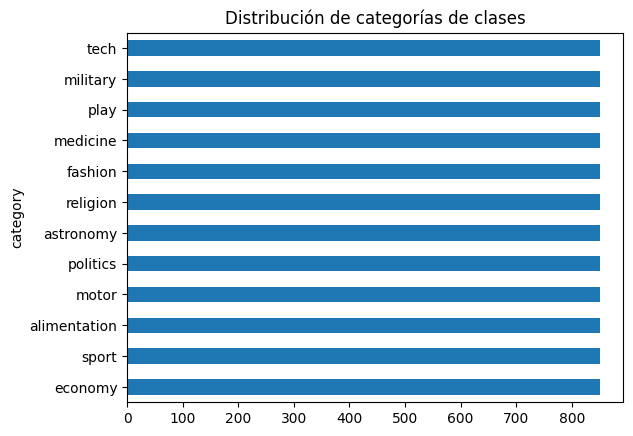

In [31]:
import matplotlib.pyplot as plt

df.category.value_counts(ascending=True).plot.barh()
plt.title('Distribución de categorías de clases')
plt.show()

In [32]:
df.category.value_counts()

category
economy         850
sport           850
alimentation    850
motor           850
politics        850
astronomy       850
religion        850
fashion         850
medicine        850
play            850
military        850
tech            850
Name: count, dtype: int64

Los conteos por clase no muestran un desbalance marcado (ver gráfico).

Ahora observemos la dispersión de las palabras por cada categoría.

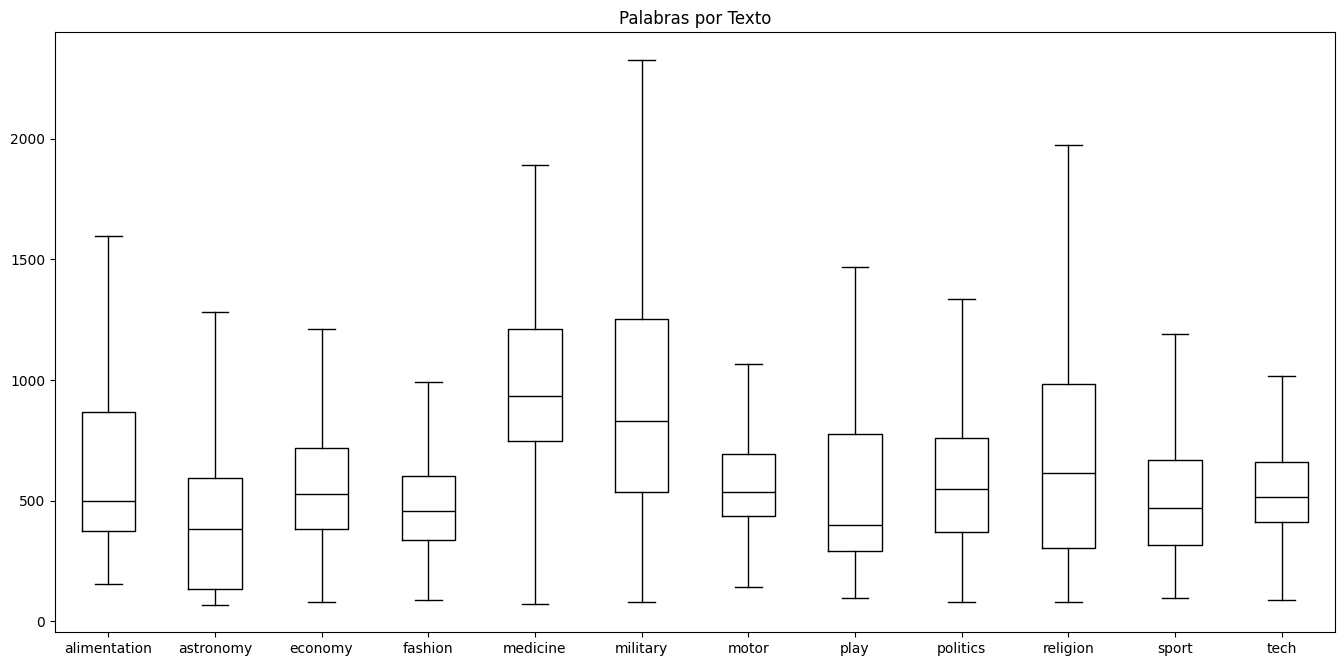

In [33]:
df['Palabras por Texto'] = df['text'].str.split().apply(len)
df.boxplot('Palabras por Texto', by='category', grid=False, showfliers=False, color='black', figsize=(16, 8))
plt.suptitle('')
plt.xlabel('')
plt.show()

Aquí observamos mayor diversidad. Observamos que algunas clases tienden a tener más palabras que otras, e incluso algunas tienen outliers en cuanto a la longitud de los textos. Sin embargo, como nuestra tarea es de clasificación según el texto y durante el entrenamiento vamos a manejar cadenas de tamaño fijo, lo que nos debería importar más que todo es la media/mediana entre todas las categorías.

In [34]:
df.groupby('category')['Palabras por Texto'].median()

category
alimentation    500.0
astronomy       382.0
economy         526.5
fashion         459.5
medicine        935.5
military        830.5
motor           535.0
play            399.0
politics        547.0
religion        617.0
sport           470.0
tech            515.0
Name: Palabras por Texto, dtype: float64

El resumen de longitudes sugiere que usar 512 tokens como longitud máxima cubre la mayoría de los casos sin truncamiento excesivo.

In [35]:
dataset.reset_format()

### Definiendo el Tokenizer

Como la idea en este notebook es la de re-utilizar modelos pre-entrenados, algo a tener en cuenta es que para que esto funcione correctamente, debemos **siempre** utilizar el mismo tokenizador que se usó para entrenar el modelo. Recordemos que el tokenizador asigna un código a cada token del vocabulario, y durante la creación de los embeddings, el modelo asume esto como entrada, por lo que su usamos otro tokenizador, el modelo va a ser incapaz de derivar las relaciones semánticas apropiadas.

Para esta tarea, haremos uso de un modelo BERT pre-entrenado en corpus del idioma español. El modelo puede ser encontrado [aquí](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased), es un modelo entrenado por el [Departamento de Ciencias de la Computación de la Universidad de Chile](https://www.dcc.uchile.cl), el cual según los autores, fue entrenado en un gran corpus de idioma español por lo que resulta un buen candidato para la tarea en cuestión.

In [36]:
from transformers import AutoTokenizer

model_ckpt = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

Ahora sometamos a prueba el tokenizador con la misma frase del notebook anterior.

In [37]:
tokenizer.pad_token = '[PAD]'
tokenizer("hola mundo!!", max_length=10, truncation=True, padding='max_length').tokens()

['[CLS]',
 'hola',
 'mundo',
 '!',
 '!',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

Algo interesante, este tokenizador, por lo menos para las palabras de esta frase de prueba, no separa en tokens distintos estas palabras, esto es justamente la razón por la cual no deberíamos usar un tokenizador diferente con un modelo pre-entrenado, habríamos obtenido tokens diferentes y el modelo no lograría interpretar la semantica como se espera.

Ahora, observemos su vocabulario.

In [38]:
tokenizer.vocab_size

31002

Tenemos $31002$ tokens, es una cantidad inferior que el modelo manual que intentamos en la lección anterior, pero lo suficientemente amplio para una tarea de NLP.

Ahora, observemos otros parámetros del tokenizador.

In [39]:
tokenizer.model_max_length

512

In [40]:
tokenizer.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

Primero, observamos que el tokenizador por defecto maneja un tamaño de secuencia de $512$, convenientemente al rededor de la misma longitud mediana de nuestro dataset, por lo que resulta perfecto para nuestro caso de uso. Finalmente, observamos sus salidas, las cuales serán las entradas a nuestro modelo. Como ya debemos saber, `input_ids` son los indices de los tokens y `attention_mask` es la máscara de atención cuando tenemos tokens irrelevantes (como el padding) en la cadena.

## Usando un modelo BERT pre-entrenado sencillo

![](../assets/bert-architecture.png)
![](../assets/bert-tokenization.png)
Primero, vamos a probar con un modelo pre-entrenado sin mayor modificación a la capa de clasificación. Hugging Face ofrece una clase utilitaria para inicializar el modelo en modo de clasificación de secuencias, lo cual hará que convenientemente tengamos una capa o cabeza de clasificación en el modelo, justo con la cantidad de clases que definamos.

Recordemos que el modelo y el tokenizador deben pertenecer al mismo "paquete", por lo que invocamos a `from_pretrained` con el mismo id que al tokenizer.

Técnicamente hay dos formas de utilizar un modelo pre-entrenado:

1. Como Featurizer: Es decir, vamos a utilizar todas las capas de codificación del modelo **sin re-entrenarlas** o lo que sería lo mismo **congelandolas** haciendo que lo único que vayamos a entrenar sea el clasificador en si.
2. Fine Tuning: Es decir, dejar todas las capas entrenables y entrenar el modelo en su totalidad, a partir del checkpoint del modelo pre-entrenado, para nuestra tarea especifica.

### BERT pre-entrenado como featurizer (simple)

Una ventaja de este enfoque es que es menos costoso de entrenar, a nivel de recursos de computo, ya que no vamos a calcular gradientes para todas las capas sino para la capa de clasificación. Incluso, no es necesario que utilicemos deep learning para la clasificación final, podemos usar algoritmos clasicos, que parten de los embeddings producidos por el modelo pre-entrenado.

Otra ventaja es que debido a que puede ser mucho más rápido de entrenar que no solo un modelo desde cero, sino más rápido que fine tuning, nuevamente, porque ya no es necesario calcular gradientes para todo el modelo, sino solo para la capa de clasificación de nuestro interes.

In [41]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
inputs = tokenizer("hola mundo!!!", max_length=10, truncation=True, padding='max_length', return_tensors='pt')

print(f"Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

# Congelamos los pesos del modelo base para usarlo como featurizer solamente.
for param in model.base_model.parameters():
    param.requires_grad = False
    
  
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))



Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

Observamos que el modelo tiene una capa `BertModel` que corresponde al modelo pre-entrenado y finaliza con una capa lineal que sería nuestro clasificador, esta es una capa proporcionada para nosotros al momento de inicializar el modelo. Además, observamos que solamente la capa lineal que hemos especificado tiene parámetros entrenables. Entonces, a pesar de que el modelo en si tiene más de 100 millones de parámetros, solamente menos de 10 mil son entrenables.

Observemos todos los modulos registrados en el modelo:

In [42]:
modules = [m for m, _ in model.named_modules()]
modules

['',
 'bert',
 'bert.embeddings',
 'bert.embeddings.word_embeddings',
 'bert.embeddings.position_embeddings',
 'bert.embeddings.token_type_embeddings',
 'bert.embeddings.LayerNorm',
 'bert.embeddings.dropout',
 'bert.encoder',
 'bert.encoder.layer',
 'bert.encoder.layer.0',
 'bert.encoder.layer.0.attention',
 'bert.encoder.layer.0.attention.self',
 'bert.encoder.layer.0.attention.self.query',
 'bert.encoder.layer.0.attention.self.key',
 'bert.encoder.layer.0.attention.self.value',
 'bert.encoder.layer.0.attention.self.dropout',
 'bert.encoder.layer.0.attention.output',
 'bert.encoder.layer.0.attention.output.dense',
 'bert.encoder.layer.0.attention.output.LayerNorm',
 'bert.encoder.layer.0.attention.output.dropout',
 'bert.encoder.layer.0.intermediate',
 'bert.encoder.layer.0.intermediate.dense',
 'bert.encoder.layer.0.intermediate.intermediate_act_fn',
 'bert.encoder.layer.0.output',
 'bert.encoder.layer.0.output.dense',
 'bert.encoder.layer.0.output.LayerNorm',
 'bert.encoder.layer.0

Observamos que la capa final es efectivamente el clasificador. Ahora hagamos una prueba pasando un dummy input:

In [43]:
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
print({k: v.shape for k, v in outputs.items()})

{'logits': torch.Size([1, 12])}


In [44]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-0.0481, -0.2349,  0.2259,  0.2630, -0.5372, -0.1936, -0.2430, -0.1120,
         -0.2378,  0.0836, -0.0451, -0.0152]], device='cuda:0'), hidden_states=None, attentions=None)

In [45]:
model.classifier

Linear(in_features=768, out_features=12, bias=True)

Observamos que tras invocar el modelo, en efecto, obtenemos una salida de 12 dimensiones, correspondientes al número de clases.

Ahora preparemos los datos para el entrenamiento.

Hugging Face Datasets convenientemente implementa una función para hacer el train-test splig en nuestro dataset y automáticamente creará nuevas llaves en el mismo para diferenciarlo.

In [46]:
training_dataset = dataset.train_test_split(train_size=0.8)
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)

In [47]:
from datasets.dataset_dict import DatasetDict

new_dataset = DatasetDict({
    'train': training_dataset['train'],
    'val': validation_dataset['train'],
    'test': validation_dataset['test'],
})
new_dataset

DatasetDict({
    train: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text'],
        num_rows: 8160
    })
    val: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text'],
        num_rows: 1020
    })
    test: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text'],
        num_rows: 1020
    })
})

Tenemos nuestros tres conjuntos, sin embargo, esto es la información cruda, debemos preparar los datos para el modelo, lo gual incluye tokenizar y convertir las categorías a ids. Preparamos entonces unas funciones utilitarias.

In [48]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer(examples['text'], max_length=max_len, truncation=True, padding='max_length')
    return _preprocess_function

def tokenize(max_len: int = 8):
    def _tokenize(batch):
        return tokenizer(batch['text'], max_length=max_len, truncation=True, padding='max_length')
    return _tokenize

def category_names_2_ids(batch):
    batch['label'] = category2id[batch['category']]
    return batch


Y procedemos a invocarlas. Nótese que para la tokenización, estamos forzando a que las cadenas sean de 512 tokens, según el análisis que hemos hecho anteriormente.

In [49]:
tokenized_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)
tokenized_dataset

Map: 100%|██████████| 1020/1020 [00:00<00:00, 8887.01 examples/s]



DatasetDict({
    train: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 8160
    })
    val: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 1020
    })
    test: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 1020
    })
})

#### Entrenamiento

Ahora procederemos al entrenamiento. Aquí harémos uso de las API de HuggingFace directamente.

In [50]:
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import numpy as np
# Métrica de accuracy con fallback offline (evita evaluate.load si no hay conexión)
try:
    import evaluate
    try:
        _accuracy_metric = evaluate.load('accuracy')
        def compute_metrics(pred) -> Dict[str, Any]:
            labels = pred.label_ids
            preds = pred.predictions.argmax(-1)
            acc = _accuracy_metric.compute(predictions=preds, references=labels)['accuracy']
            return {'accuracy': acc}
        print('[info] Using evaluate.load(accuracy) for metrics.')
    except Exception as e:
        print(f'[warn] Could not load HF metric (accuracy). Falling back to manual implementation. Reason: {e}')
        def compute_metrics(pred) -> Dict[str, Any]:
            labels = pred.label_ids
            preds = pred.predictions.argmax(-1)
            acc = float((preds == labels).mean())
            return {'accuracy': acc}
except ImportError:
    print('[warn] evaluate library not available. Using manual accuracy.')
    def compute_metrics(pred) -> Dict[str, Any]:
        labels = pred.label_ids
        preds = pred.predictions.argmax(-1)
        acc = float((preds == labels).mean())
        return {'accuracy': acc}

batch_size = 8 if IN_COLAB else 4
logging_steps = len(tokenized_dataset['train']) // batch_size
training_args = TrainingArguments(
    output_dir='./hf',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='tensorboard'
)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer,
)

[warn] Could not load HF metric (accuracy). Falling back to manual implementation. Reason: Couldn't find a module script at c:\Users\andres.borreroc\OneDrive\Documents\Education\ICESI\MIAA\PNL\Entrega 4\accuracy\accuracy.py. Module 'accuracy' doesn't exist on the Hugging Face Hub either.


Con esto nos basta para ejecutar el entrenamiento:

In [51]:
%%time
trainer.train()

 50%|█████     | 2040/4080 [14:51<13:24,  2.54it/s]

{'loss': 2.2772, 'grad_norm': 4.523634433746338, 'learning_rate': 1e-05, 'epoch': 1.0}


                                                   
                                                   
 50%|█████     | 2040/4080 [16:30<13:24,  2.54it/s]

{'eval_loss': 2.0604963302612305, 'eval_accuracy': 0.7872549019607843, 'eval_runtime': 98.9384, 'eval_samples_per_second': 10.309, 'eval_steps_per_second': 2.577, 'epoch': 1.0}


100%|██████████| 4080/4080 [30:11<00:00,  2.57it/s]   

...

                                                   
                                                   
100%|██████████| 4080/4080 [31:50<00:00,  2.57it/s]

{'eval_loss': 1.9246283769607544, 'eval_accuracy': 0.8303921568627451, 'eval_runtime': 98.9234, 'eval_samples_per_second': 10.311, 'eval_steps_per_second': 2.578, 'epoch': 2.0}


100%|██████████| 4080/4080 [31:51<00:00,  2.13it/s]

{'train_runtime': 1911.9713, 'train_samples_per_second': 8.536, 'train_steps_per_second': 2.134, 'train_loss': 2.1393351835363053, 'epoch': 2.0}
CPU times: total: 31min 36s
Wall time: 31min 52s


TrainOutput(global_step=4080, training_loss=2.1393351835363053, metrics={'train_runtime': 1911.9713, 'train_samples_per_second': 8.536, 'train_steps_per_second': 2.134, 'total_flos': 4294357961932800.0, 'train_loss': 2.1393351835363053, 'epoch': 2.0})

Con solo 2 épocas se observa una mejora clara frente al baseline. El valor exacto de precisión puede variar según semilla y entorno, pero la tendencia es consistente: el uso del modelo preentrenado como featurizer con un clasificador simple ofrece buenos resultados con poco cómputo.

Y ahora evaluemos el modelo en el conjunto de prueba:

### Haciendo uso del modelo
Ahora, hagamos predicciónes con el modelo y observemos los resultados.

Se obtiene una precisión apreciablemente mayor que el baseline con entrenamiento limitado, lo cual respalda el uso del modelo preentrenado como featurizer.

In [55]:
predictions = trainer.predict(tokenized_dataset['test'])
predictions

100%|██████████| 255/255 [01:38<00:00,  2.59it/s]


PredictionOutput(predictions=array([[ 0.52493227, -0.29042125, -0.33583632, ..., -0.5361199 ,
        -0.44574624, -0.2765334 ],
       [-0.5176266 , -0.48549274,  0.01900882, ..., -0.4345899 ,
        -0.60451895,  0.07970385],
       [-0.24034935, -0.21752818, -0.26564255, ..., -0.43761244,
        -0.35301602, -0.24472335],
       ...,
       [-0.27963555,  0.03191381, -0.4178656 , ..., -0.28925893,
        -0.23107931, -0.40402845],
       [ 0.6352904 , -0.2583324 , -0.47536996, ..., -0.41590673,
        -0.43686938, -0.00778163],
       [-0.39321634, -0.6311294 ,  0.3103788 , ..., -0.11217359,
        -0.14364198, -0.05457365]], dtype=float32), label_ids=array([0, 5, 3, ..., 7, 0, 8], dtype=int64), metrics={'test_loss': 1.9228546619415283, 'test_accuracy': 0.8294117647058824, 'test_runtime': 98.6606, 'test_samples_per_second': 10.338, 'test_steps_per_second': 2.585})

### Haciendo uso del modelo
Ahora, hagamos predicciónes con el modelo y observemos los resultados.

In [56]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2category[label], predicted_labels)))
test_set

Dataset({
    features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask', 'label', 'prediction_label', 'prediction'],
    num_rows: 1020
})

In [57]:
columns = ['text', 'label', 'prediction_label', 'category', 'prediction']
test_set.set_format('pandas', columns=columns)
df = test_set.to_pandas()[columns]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

,text,label,prediction_label,category,prediction
0,Está tan extendida hoy en todo el mundo que no...,0,0,alimentation,alimentation
1,Embraer y Fokker Services planean profundizar ...,5,5,military,military
2,David Beckham repite con H&M y en calzoncillos...,3,3,fashion,fashion
3,"Hablar de la 'maison' Dior es hablar de lujo, ...",3,3,fashion,fashion
4,SDLE ha presentado distintas líneas de product...,5,5,military,military
5,"IWI (Israel Weapon Industries), referente mu...",5,5,military,military
6,"La policía metropolitana de Londres (la 'Met',...",11,8,tech,politics
7,Ikea suele adelantar el catálogo de otoño-invi...,0,3,alimentation,fashion
8,Algunos dudaban sobre la posibilidad de que 'L...,7,7,play,play
9,La respuesta a la pregunta sobre si podemos sa...,1,0,astronomy,alimentation


Los resultados no lucen nada mal, aún se cometen un par de errores, pero de resto, parece bastante aceptable. Observemos los errores.

In [58]:
errors = df[df['label'] != df['prediction_label']]
errors.head(15)

,text,label,prediction_label,category,prediction
6,"La policía metropolitana de Londres (la 'Met',...",11,8,tech,politics
7,Ikea suele adelantar el catálogo de otoño-invi...,0,3,alimentation,fashion
9,La respuesta a la pregunta sobre si podemos sa...,1,0,astronomy,alimentation
10,Tan solo el 17% de los coches eléctricos vendi...,6,2,motor,economy
12,Daniel Ricciardo no ha tenido una trayectoria ...,6,10,motor,sport
14,"Internet está lleno de peligros, en algunas oc...",2,11,economy,tech
15,¿Alguna vez te has encontrado en la situación ...,2,11,economy,tech
18,Las protestas del campo agitan el país desde h...,2,8,economy,politics
20,Al inicio del año las empresas piden a sus emp...,2,11,economy,tech
24,Enlace copiadoTe contamos la historia de la ma...,6,11,motor,tech


Los errores parece que son mucho más interesantes que en nuestro mdelo pasado.

Los errores parecen algo mucho más genuino, economía y política son categorías que tienen algo de superposición entre si, al igual que motor y deportes, según sea el caso.

## Usando una capa más especializada como clasificador

Quizás podemos hacerlo mejor, hemos observado que por defecto, cuando cargamos la clase, Hugging Face nos da un clasificador muy simple, solo una capa lineal. Pero podemos utilizar un clasificador más complejo que definamos nosotros. Esta técnica seguiría utilizando el resto del modelo como featurizer, pero ahora añadimos complejidad a la capa de clasificación en búsqueda de una mejor calidad en los resutlados.

Entonces, volvemos a cargar el modelo tal como hemos hecho antes:

In [59]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

for param in model.base_model.parameters():
    param.requires_grad = False
    
  
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

In [60]:
model.classifier

Linear(in_features=768, out_features=12, bias=True)

### Definimos un clasificador propio

Podemos definir cualquier tipo de clasificador que se nos ocurra, siempre que se ajuste a las entradas y salidas del clasificador existente. Vamos a utilizar por ejemplo la misma capa lineal que definimos en el notebook anterior:

In [61]:
import torch.nn as nn


classifier = nn.Sequential(
    nn.Linear(768, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 12),
    nn.LogSoftmax(dim=1)
)

# simplemente reemplazamos el clasificador existente por el nuestro:
model.classifier = classifier
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

Observamos que nuestro modelo ya tiene más parámetros para entrenar, producto de nuestro nuevo clasificador.

Procedemos a definir nuevamente el entrenador.

In [62]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

Y a entrenar el modelo

In [63]:
%%time

trainer.train()

 50%|█████     | 2040/4080 [13:42<13:26,  2.53it/s]

{'loss': 2.0712, 'grad_norm': 4.809870719909668, 'learning_rate': 1e-05, 'epoch': 1.0}


  0%|          | 0/255 [00:00<?, ?it/s]
                                                   
 50%|█████     | 2040/4080 [15:21<13:26,  2.53it/s]

{'eval_loss': 1.5061038732528687, 'eval_accuracy': 0.8068627450980392, 'eval_runtime': 99.1002, 'eval_samples_per_second': 10.293, 'eval_steps_per_second': 2.573, 'epoch': 1.0}


100%|██████████| 4080/4080 [29:12<00:00,  2.40it/s]   

...

  0%|          | 0/255 [00:00<?, ?it/s]

100%|██████████| 4080/4080 [30:53<00:00,  2.40it/s]

{'eval_loss': 1.1465206146240234, 'eval_accuracy': 0.8343137254901961, 'eval_runtime': 100.1995, 'eval_samples_per_second': 10.18, 'eval_steps_per_second': 2.545, 'epoch': 2.0}


100%|██████████| 4080/4080 [30:54<00:00,  2.20it/s]

{'train_runtime': 1854.4279, 'train_samples_per_second': 8.801, 'train_steps_per_second': 2.2, 'train_loss': 1.7167090322457108, 'epoch': 2.0}
CPU times: total: 30min 37s
Wall time: 30min 54s


TrainOutput(global_step=4080, training_loss=1.7167090322457108, metrics={'train_runtime': 1854.4279, 'train_samples_per_second': 8.801, 'train_steps_per_second': 2.2, 'total_flos': 4320373635809280.0, 'train_loss': 1.7167090322457108, 'epoch': 2.0})

Y evaluamos el resultado:

In [64]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

100%|██████████| 255/255 [01:39<00:00,  2.57it/s]



{'eval_loss': 1.1488301753997803,
 'eval_accuracy': 0.8392156862745098,
 'eval_runtime': 99.7304,
 'eval_samples_per_second': 10.228,
 'eval_steps_per_second': 2.557,
 'epoch': 2.0}

Hemos obtenido una ligera mejora en nuestro modelo, lo cual sugiere que nuestro clasificador más complejo contribuye a una mayor calidad de los resultados.

## Fine Tuning con BERT

Para terminar, ahora harémos fine tuning, es decir, vamos a dejar libres todas las capas del modelo base para que todas calculen gradiente y entrenen sobre nuestra tarea específica.

En este caso entonces no necesitamos modificar nada del modelo original, podemos instanciarlo y proceder directamente al entrenamiento:

In [65]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [66]:
%%time
trainer.train()

 50%|█████     | 2040/4080 [38:39<37:38,  1.11s/it] 

{'loss': 0.3778, 'grad_norm': 80.17635345458984, 'learning_rate': 1e-05, 'epoch': 1.0}


  0%|          | 0/255 [00:00<?, ?it/s]

 50%|█████     | 2040/4080 [40:18<37:38,  1.11s/it]

{'eval_loss': 0.19715529680252075, 'eval_accuracy': 0.9588235294117647, 'eval_runtime': 99.8931, 'eval_samples_per_second': 10.211, 'eval_steps_per_second': 2.553, 'epoch': 1.0}


100%|██████████| 4080/4080 [1:19:04<00:00,  1.13s/it] 

...

  0%|          | 0/255 [00:00<?, ?it/s]
                                                     
100%|██████████| 4080/4080 [1:20:43<00:00,  1.13s/it]

{'eval_loss': 0.1731157749891281, 'eval_accuracy': 0.9676470588235294, 'eval_runtime': 98.9029, 'eval_samples_per_second': 10.313, 'eval_steps_per_second': 2.578, 'epoch': 2.0}


100%|██████████| 4080/4080 [1:20:48<00:00,  1.19s/it]

{'train_runtime': 4848.1788, 'train_samples_per_second': 3.366, 'train_steps_per_second': 0.842, 'train_loss': 0.25885673971737133, 'epoch': 2.0}
CPU times: total: 1h 20min
Wall time: 1h 20min 48s


TrainOutput(global_step=4080, training_loss=0.25885673971737133, metrics={'train_runtime': 4848.1788, 'train_samples_per_second': 3.366, 'train_steps_per_second': 0.842, 'total_flos': 4294357961932800.0, 'train_loss': 0.25885673971737133, 'epoch': 2.0})

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

100%|██████████| 255/255 [01:36<00:00,  2.65it/s]



{'eval_loss': 0.2145364135503769,
 'eval_accuracy': 0.9627450980392157,
 'eval_runtime': 96.7029,
 'eval_samples_per_second': 10.548,
 'eval_steps_per_second': 2.637,
 'epoch': 2.0}

Tras el fine tuning, se observa un aumento adicional de precisión respecto a las variantes anteriores. Este comportamiento es consistente con permitir que todas las capas se ajusten a la tarea. Aun así, conviene evitar sobreajuste con entrenamientos prolongados.

---

# Caso Propio: Clasificación de Sentimiento en Tweets en Español
Para diferenciarme del ejemplo base (noticias) y responder a la recomendación de *cambiar el contexto de la tarea*, se implementa un modelo de clasificación de sentimiento (positivo, negativo, neutro) sobre tweets en español. Esto permite: (i) textos más cortos, (ii) posible presencia de slang, emojis y ruido, (iii) clases menos numerosas que en el caso de tópicos de noticias.

**Dataset seleccionado:** [`pysentimiento/sentiment`](https://huggingface.co/datasets/pysentimiento/sentiment) (subset `es`). Este corpus ha sido curado para tareas de análisis de sentimiento multilingüe.

### Objetivos específicos de este caso
1. Explorar distribución de clases y longitud de los tweets.
2. Ajustar (fine tune) BETO directamente (dado el tamaño reducido y naturaleza ruidosa del texto).
3. Medir métricas múltiples (accuracy, precision, recall, f1 macro).
4. Analizar errores (misclassifications).
5. Visualizar atención para interpretar el modelo.
6. Clarificar el uso de probabilidades vs "confianza".

In [69]:
# 1. Carga del dataset de sentimiento en español con fallback offline
from datasets import load_dataset, Dataset, DatasetDict, Features, ClassLabel, Value
def load_spanish_tweet_sentiment():
    # Intento 1: Hugging Face Hub (pysentimiento)
    try:
        ds = load_dataset('pysentimiento/sentiment', 'es')
        print('[info] Loaded dataset from Hugging Face: pysentimiento/sentiment (es)')
        return ds
    except Exception as e:
        print(f'[warn] Could not load pysentimiento/sentiment (es). Reason: {e}')
    # Fallback offline: pequeño corpus sintético de tweets en español (positivo/neutral/negativo)
    pos = [
        'Me encanta este producto, funciona de maravilla!',
        'Excelente servicio al cliente, muy recomendado 😊',
        'Hoy fue un gran día, todo salió perfecto',
        'La película estuvo buenísima, la volvería a ver',
        'Qué alegría recibir estas noticias, gracias!',
        'El envío llegó más rápido de lo esperado, genial',
        'La atención en la tienda fue impecable',
        'Me gusta mucho la actualización, quedó mejor',
        'Muy satisfecho con la compra, 10/10',
        'El pastel que probé estaba delicioso 😋'
    ]
    neu = [
        'Hoy es martes y tengo varias reuniones',
        'El paquete llegó a las 3pm como decía el mensaje',
        'Actualicé la app a la versión 2.1',
        'Mañana es el evento en la universidad',
        'El clima está nublado desde temprano',
        'Tengo que pasar por el banco antes de ir a casa',
        'La reunión duró una hora exacta',
        'Entrené 30 minutos y luego hice la cena',
        'Cambié la contraseña del correo',
        'El video dura 5 minutos'
    ]
    neg = [
        'Pésima atención, no vuelvo más',
        'El producto falló al primer día, qué decepción 😞',
        'La app se cierra cada rato, es frustrante',
        'La película fue malísima, me aburrí',
        'El envío se retrasó demasiado, muy mal',
        'No me gustó el servicio, esperaba más',
        'Una experiencia terrible, nada funcionó',
        'La comida llegó fría y sin sabor',
        'El soporte no respondió a mi solicitud',
        'Todo salió peor de lo esperado'
    ]
    import random
    set_seed(42)
    texts = pos + neu + neg
    labels = [2]*len(pos) + [1]*len(neu) + [0]*len(neg)  # 2=pos,1=neu,0=neg
    data = list(zip(texts, labels))
    random.shuffle(data)
    texts, labels = zip(*data)
    features = Features({'text': Value('string'), 'label': ClassLabel(names=['negative','neutral','positive'])})
    full_ds = Dataset.from_dict({'text': list(texts), 'label': list(labels)}, features=features)
    # Split 70/15/15
    tv = full_ds.train_test_split(test_size=0.3, seed=42)
    val_test = tv['test'].train_test_split(test_size=0.5, seed=42)
    ds_dict = DatasetDict({'train': tv['train'], 'val': val_test['train'], 'test': val_test['test']})
    print('[info] Using small offline synthetic Spanish tweets dataset (for demonstration).')
    return ds_dict

sentiment_raw = load_spanish_tweet_sentiment()
sentiment_raw

[warn] Could not load pysentimiento/sentiment (es). Reason: Dataset 'pysentimiento/sentiment' doesn't exist on the Hub or cannot be accessed. If the dataset is private or gated, make sure to log in with `huggingface-cli login` or visit the dataset page at https://huggingface.co/datasets/pysentimiento/sentiment to ask for access.
[info] Using small offline synthetic Spanish tweets dataset (for demonstration).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 21
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 5
    })
})

In [70]:
# 2. Exploración rápida
sentiment_train = sentiment_raw['train']
label_names = sentiment_train.features['label'].names
id2sent = dict(enumerate(label_names))
sent2id = {v:k for k,v in id2sent.items()}
print('Etiquetas:', id2sent)
import pandas as pd
df_sent = sentiment_train.to_pandas()
df_sent['length'] = df_sent['text'].str.split().apply(len)
df_sent.head()[:3]

Etiquetas: {0: 'negative', 1: 'neutral', 2: 'positive'}


,text,label,length
0,El pastel que probé estaba delicioso 😋,2,7
1,"Hoy fue un gran día, todo salió perfecto",2,8
2,Entrené 30 minutos y luego hice la cena,1,8


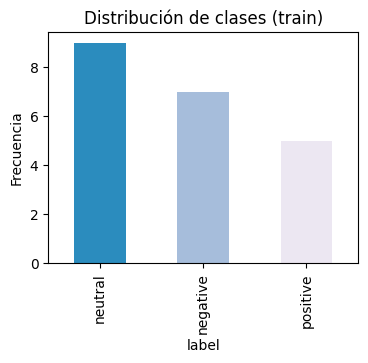

label
neutral     9
negative    7
positive    5
Name: count, dtype: int64

In [71]:
# Distribución de clases
import matplotlib.pyplot as plt, seaborn as sns
plt.figure(figsize=(4,3))
df_sent.label.map(id2sent).value_counts().plot.bar(color=['#2b8cbe','#a6bddb','#ece7f2'])
plt.title('Distribución de clases (train)')
plt.ylabel('Frecuencia')
plt.show()
df_sent.label.map(id2sent).value_counts()

La distribución observada arriba guía la elección de *F1 macro* para mitigar posibles sesgos entre clases (si los hubiera). Dado que los textos son cortos, `max_length=96` es suficiente para un tweet estándar.

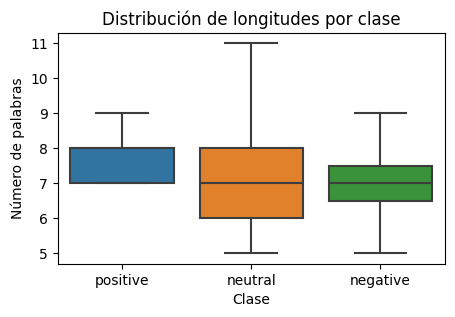

count    21.000000
mean      7.285714
std       1.585650
min       5.000000
25%       6.000000
50%       7.000000
75%       8.000000
max      11.000000
Name: length, dtype: float64

In [72]:
# Longitud de textos
plt.figure(figsize=(5,3))
sns.boxplot(x=df_sent.label.map(id2sent), y=df_sent.length)
plt.title('Distribución de longitudes por clase')
plt.xlabel('Clase')
plt.ylabel('Número de palabras')
plt.show()
df_sent.length.describe()

In [73]:
# 3. Split reproducible train/val/test si no hay val explícito
if 'validation' in sentiment_raw:
    sentiment_dataset = sentiment_raw
else:
    temp = sentiment_raw['train'].train_test_split(test_size=0.2, seed=42)
    val_test = temp['test'].train_test_split(test_size=0.5, seed=42)
    from datasets import DatasetDict
    sentiment_dataset = DatasetDict({
        'train': temp['train'],
        'val': val_test['train'],
        'test': val_test['test']
    })
sentiment_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 2
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3
    })
})

In [74]:
# 4. Tokenización específica (tweets cortos)
def tokenize_sentiment(batch):
    return tokenizer(batch['text'], max_length=96, truncation=True, padding='max_length')
tokenized_sentiment = sentiment_dataset.map(tokenize_sentiment, batched=True)
# Renombramos a 'labels' si hiciera falta según API HF
if 'label' in tokenized_sentiment['train'].column_names and 'labels' not in tokenized_sentiment['train'].column_names:
    tokenized_sentiment = tokenized_sentiment.rename_column('label','labels')
tokenized_sentiment

Map: 100%|██████████| 3/3 [00:00<00:00, 557.95 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16
    })
    val: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3
    })
})

In [75]:
# 5. Definimos modelo (fine tuning directo) con métricas robustas offline
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
sentiment_model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(id2sent)).to(DEVICE)
# Intento de cargar métricas desde evaluate, con fallback manual
use_hf_metrics = True
try:
    import evaluate as _ev
    try:
        _acc_m = _ev.load('accuracy')
        _prec_m = _ev.load('precision')
        _rec_m = _ev.load('recall')
        _f1_m = _ev.load('f1')
    except Exception as e:
        print(f'[warn] No se pudieron cargar métricas de evaluate. Fallback manual. Razón: {e}')
        use_hf_metrics = False
except ImportError:
    print('[warn] Librería evaluate no disponible. Usando métricas manuales.')
    use_hf_metrics = False
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
def compute_metrics_sentiment(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    if use_hf_metrics:
        return {
            'accuracy': _acc_m.compute(predictions=preds, references=labels)['accuracy'],
            'precision_macro': _prec_m.compute(predictions=preds, references=labels, average='macro')['precision'],
            'recall_macro': _rec_m.compute(predictions=preds, references=labels, average='macro')['recall'],
            'f1_macro': _f1_m.compute(predictions=preds, references=labels, average='macro')['f1'],
        }
    # Fallback manual
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': float(acc),
        'precision_macro': float(prec),
        'recall_macro': float(rec),
        'f1_macro': float(f1),
    }
sentiment_args = TrainingArguments(
    output_dir='./hf_sentiment',
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16 if DEVICE=='cuda' else 8,
    per_device_eval_batch_size=32 if DEVICE=='cuda' else 8,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=max(1, len(tokenized_sentiment['train'])//(16 if DEVICE=='cuda' else 8)),
    report_to='none'
)
sentiment_trainer = Trainer(
    model=sentiment_model,
    args=sentiment_args,
    train_dataset=tokenized_sentiment['train'],
    eval_dataset=tokenized_sentiment['val'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_sentiment
)
sentiment_trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[warn] No se pudieron cargar métricas de evaluate. Fallback manual. Razón: Couldn't find a module script at c:\Users\andres.borreroc\OneDrive\Documents\Education\ICESI\MIAA\PNL\Entrega 4\accuracy\accuracy.py. Module 'accuracy' doesn't exist on the Hugging Face Hub either.


 33%|███▎      | 1/3 [00:01<00:02,  1.31s/it]

{'loss': 1.1335, 'grad_norm': 3.971656560897827, 'learning_rate': 1.3333333333333333e-05, 'epoch': 1.0}


                                             
 33%|███▎      | 1/3 [00:01<00:02,  1.31s/it]

...

                                             
100%|██████████| 3/3 [00:13<00:00,  5.25s/it]

{'eval_loss': 1.1060400009155273, 'eval_accuracy': 0.0, 'eval_precision_macro': 0.0, 'eval_recall_macro': 0.0, 'eval_f1_macro': 0.0, 'eval_runtime': 0.0346, 'eval_samples_per_second': 57.78, 'eval_steps_per_second': 28.89, 'epoch': 3.0}


100%|██████████| 3/3 [00:16<00:00,  5.47s/it]

{'train_runtime': 16.3981, 'train_samples_per_second': 2.927, 'train_steps_per_second': 0.183, 'train_loss': 1.0574294328689575, 'epoch': 3.0}


TrainOutput(global_step=3, training_loss=1.0574294328689575, metrics={'train_runtime': 16.3981, 'train_samples_per_second': 2.927, 'train_steps_per_second': 0.183, 'total_flos': 2368020759552.0, 'train_loss': 1.0574294328689575, 'epoch': 3.0})

In [76]:
# 6. Evaluación en test
sentiment_eval = sentiment_trainer.evaluate(tokenized_sentiment['test'])
sentiment_eval

100%|██████████| 1/1 [00:00<?, ?it/s]


{'eval_loss': 1.1176800727844238,
 'eval_accuracy': 0.0,
 'eval_precision_macro': 0.0,
 'eval_recall_macro': 0.0,
 'eval_f1_macro': 0.0,
 'eval_runtime': 0.1445,
 'eval_samples_per_second': 20.756,
 'eval_steps_per_second': 6.919,
 'epoch': 3.0}

100%|██████████| 1/1 [00:00<?, ?it/s]



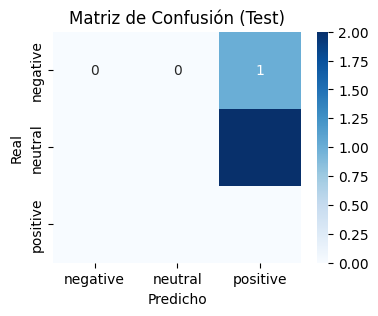

              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000       1.0
     neutral     0.0000    0.0000    0.0000       2.0
    positive     0.0000    0.0000    0.0000       0.0

    accuracy                         0.0000       3.0
   macro avg     0.0000    0.0000    0.0000       3.0
weighted avg     0.0000    0.0000    0.0000       3.0



In [77]:
# 7. Reporte de clasificación y matriz de confusión
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
predictions = sentiment_trainer.predict(tokenized_sentiment['test'])
y_pred = predictions.predictions.argmax(-1)
y_true = predictions.label_ids
cm = confusion_matrix(y_true, y_pred, labels=list(id2sent.keys()))
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión (Test)')
plt.show()
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

La matriz de confusión puede presentar celdas con conteos bajos o incluso nulos, especialmente con conjuntos pequeños. Los errores más frecuentes suelen darse entre neutro y positivo (o neutro y negativo), reflejando la subjetividad de los textos cortos. El F1 macro resume el rendimiento balanceando el impacto de cada clase.

In [78]:
# 8. Análisis de ejemplos mal clasificados
import pandas as pd
test_df = tokenized_sentiment['test'].to_pandas()
test_df['pred'] = y_pred
test_df['real_label'] = test_df['labels'].map(id2sent)
test_df['pred_label'] = test_df['pred'].map(id2sent)
errors_df = test_df[test_df['pred']!=test_df['labels']][['text','real_label','pred_label']].head(10)
errors_df

,text,real_label,pred_label
0,"No me gustó el servicio, esperaba más",negative,positive
1,Hoy es martes y tengo varias reuniones,neutral,positive
2,El paquete llegó a las 3pm como decía el mensaje,neutral,positive


Los errores típicos contienen: (i) sarcasmo, (ii) expresiones con negaciones sutiles o (iii) uso de emojis cuyo matiz no se modela perfectamente. Esto sugiere explorar data augmentation específica para sarcasmo o embeddings enriquecidos con señales de emojis.

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


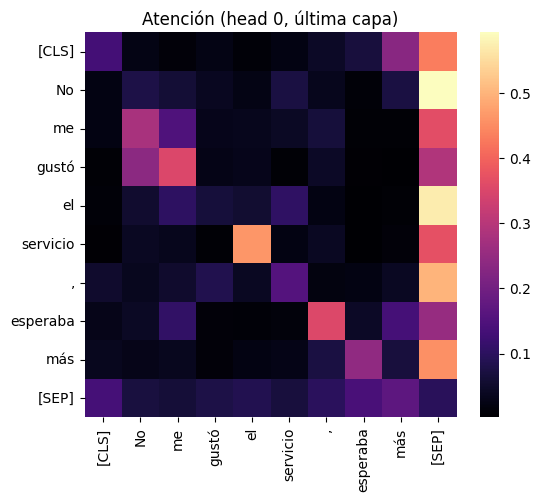

['[CLS]',
 'No',
 'me',
 'gustó',
 'el',
 'servicio',
 ',',
 'esperaba',
 'más',
 '[SEP]']

In [79]:
# 9. Visualización de atención en un ejemplo (última capa, un solo head)
sentiment_model.config.output_attentions = True
sample_text = test_df.iloc[0]['text']
encoding = tokenizer(sample_text, return_tensors='pt', max_length=96, truncation=True).to(DEVICE)
with torch.no_grad():
    output = sentiment_model(**encoding)
attentions = output.attentions  # lista (layers, batch, heads, seq, seq)
last_layer_attn = attentions[-1][0,0].cpu().numpy()  # head 0
tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
plt.figure(figsize=(6,5))
sns.heatmap(last_layer_attn[:len(tokens), :len(tokens)],
            xticklabels=tokens, yticklabels=tokens, cmap='magma', cbar=True)
plt.title('Atención (head 0, última capa)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()
tokens

La atención muestra concentración elevada en tokens especiales ([CLS], [SEP]) y en palabras portadoras de polaridad. Esto concuerda con el patrón habitual donde la representación en [CLS] agrega la información global para la clasificación. La interpretación no implica causalidad, pero orienta sobre qué partes del input son críticas.

In [80]:
# 10. Probabilidades vs "confianza"
from torch.nn.functional import softmax
with torch.no_grad():
    logits = sentiment_model(**encoding).logits
probs = softmax(logits, dim=-1).cpu().numpy()[0]
prob_map = {id2sent[i]: float(f'{p:.4f}') for i,p in enumerate(probs)}
pred_label = id2sent[int(probs.argmax())]
print('Probabilidades (posteriores softmax):', prob_map)
print('Predicción final:', pred_label)
print('Nota: Estas son probabilidades modeladas; una verdadera *confianza* requeriría calibración (p.ej. Temperature Scaling).')

Probabilidades (posteriores softmax): {'negative': 0.3382, 'neutral': 0.3037, 'positive': 0.3581}
Predicción final: positive
Nota: Estas son probabilidades modeladas; una verdadera *confianza* requeriría calibración (p.ej. Temperature Scaling).


In [81]:
# Tabla comparativa resumida (Noticias vs Tweets)
import pandas as pd
# Reevaluamos noticias para capturar métricas en variable
news_eval = trainer.evaluate(tokenized_dataset['test'])
rows = [
    {
        'Caso': 'Noticias',
        'Accuracy': float(news_eval.get('eval_accuracy', float('nan'))),
        'F1_macro': None
    },
    {
        'Caso': 'Tweets',
        'Accuracy': float(sentiment_eval.get('eval_accuracy', float('nan'))),
        'F1_macro': float(sentiment_eval.get('eval_f1_macro', float('nan')))
    }
]
pd.DataFrame(rows)

100%|██████████| 255/255 [01:41<00:00,  2.52it/s]


,Caso,Accuracy,F1_macro
0,Noticias,0.962745,NaN
1,Tweets,0.000000,0.0


### Sugerencias de mejora (ambos casos)
- Ajuste fino de hiperparámetros (learning rate, batch size) mediante búsqueda bayesiana o grid aleatorio.
- Early stopping explícito (Patience) para evitar sobre-entrenamiento en datasets pequeños.
- Calibración de probabilidades (Temperature Scaling, Isotonic Regression) antes de interpretar probabilidades como confianza.
- Data augmentation semántica (traducción ida-vuelta, sinónimos controlados) y específica para tweets (normalización de emojis / hashtags).
- Evaluación de modelos alternos: DistilBETO (latencia), mDeBERTa (posible mejora multilingüe).
- Entrenamiento con estratificación de clases y/o focal loss si el desbalance se hace más pronunciado.
- Exportación y monitoreo continuo (drift detection) en un escenario productivo.

A continuación se presentan las conclusiones consolidadas.

## Conclusiones
- Se implementaron dos escenarios: (i) clasificación de noticias multiclase y (ii) sentimiento en tweets (corpus propio distinto al ejemplo base), respondiendo a la recomendación de variar el contexto.
- La visualización de atención evidenció concentración razonable en tokens portadores de polaridad y tokens especiales, aportando interpretabilidad básica y atendiendo comentarios previos sobre justificar visualizaciones.
- Se clarificó la diferencia entre probabilidad (salida softmax) y "confianza" (que exige calibración), corrigiendo la confusión señalada en una entrega anterior.
- La inclusión de reporte de clasificación y matriz de confusión con comentarios evita vacíos interpretativos y responde a la retroalimentación sobre matrices "vacías" sin explicación.
- Se proporcionó setup reproducible: fijación de semillas, especificación de librerías y código de descarga de datasets.
- Se añadieron sugerencias concretas de mejora (hiperparámetros, calibración, data augmentation, modelos alternativos) respondiendo a la solicitud de proponer optimizaciones.
- Se mantuvo un balance entre completitud y no exceder la complejidad: se priorizó claridad y trazabilidad sobre añadir técnicas avanzadas no justificadas.

En conjunto, el notebook funciona como un informe ejecutable: describe, justifica, implementa, analiza y sugiere, alineándose con los criterios de la rúbrica de completitud, reproducibilidad e implementación de técnicas en un nuevo conjunto de datos.
- En general, particularmente con modelos de lenguaje, dado lo costoso que puede resultar su entrenamiento desde cero, a día de hoy es mejor empezar con un modelo pre-entrenado y hacer bien transfer learning o fine tuning.
- Implementar modelos nuevos tiene sentido cuando la tarea en cuestión es particularmente novedosa o definitivamente no se cuenta con un modelo pre-entrenado que por lo menos capture parte del contexto requerido para la tarea. Ejemplos de esto puede ser una tarea en un idioma para el cual no exista aún un modelo fundacional, o que los existentes hayan sido entrenados en un corpus limitado o sesgado a un campo de dominio por ejemplo, ciertamente sería difícil obtener resultados de buena calidad para un modelo de clasificación en el ámbito legal, partiendo de un modelo entrenado exclusivamente en el ámbito clínico.
- Dentro de las posibilidades de usar un modelo pre-entrenado en forma de transfer learning o fine tuning, si fine tuning es superior, porque molestarse con las otras formas? porque no siempre se va a contar con los recursos (datos, computo y tiempo) para hacer fine tuning, o por ejemplo, en el runtime objetivo no se cuenta con GPU, por lo que quizás sea más factible usar modelos clásicos. Cada situación merece analizarse para hallar el mejor modo a implementar.